# Cohere Labs Scholars 2️⃣0️⃣2️⃣6️⃣ : TakeHome Assignment

# **Background**

Welcome to the Cohere Labs Scholars Program Take-Home Challenge! This exercise is designed to allow you to showcase your engineering and problem solving skills. The Assessment consists of different challenges including:

*   Identifying bugs, and getting the code working. This is designed to test your ability to grapple with real world engineering challenges.
*   Testing your ability to generate code for a specified problem.
*   An opportunity for you to attempt an optional challenge question that extends the original problem set.

These tasks were chosen as a setting to see how you think about problems, even if they are not in your own research field of interest. The tasks and dataset are not meant to be indicative of the research goals of the Scholar Program. We purposefully have selected a simple toy problem so the focus is on how you think, and does not require significant machine learning resources (can be run in this colab).

Good luck! 🍀

**How to Use and Submit this Document?**

*   Make a copy of this document and rename it **Firstname_Lastname_ScholarsTakehome**
* Once you have completed all tasks:
  * Save and pin your revisions
  * Download the colab as a .ipynb file
  * Submit the assignment via the submission link you received via email (subject line: "Cohere Labs: Research Scholar Program - Next Steps") by **September 16 by 11pm PDT**.


### This Coding Challenge(🚨 25 points) consists of 4 parts :

1. **Debugging custom SmolMoELM** 🔍🐛[*10 points*]
2. **Upcycling a Dense Model into an MoE 🔄 🚴** [*3 points*]
3. **Continued Pretraining 📚💪** [*7 points*]
4. **Exploring The Unknown 🧙 ✨** [*5 points*]

Each of these build on top of each other so you are encouraged to work through them in order.

**NOTE**: Part 4 can also be attempted independently(*if you don't wish to build on the previous section*)

## **Coding Challenge Part 1: Debugging custom Smol`MoE`LM 🔍🐛 [🚨 10 points]**

**Mixture of Experts (MoE)** are all the rage in 2025, powering some of the most advanced large-scale AI systems. In this coding challenge, you are required to dive into the core idea behind MoE and fix a bare-bones implementation.

We have **🚨 10 bugs** in the following implementation.
There is a section `3.Test` for your convenience to verify you have correctly identified all the bugs(Both `Check #1` and `Check #2` will help you confirm this).

**Rules**:
1. **Bug Definition:**
  - There are **🚨 10 bugs** to be fixed.
  - A bug is *defined as **{incorrect, missing, unnecessary}** lines of code*.
  - You earn 1 point for each correctly identified and fixed bug.
2. **Fix Guidelines:**
  - You are encouraged to make the smallest possible fix, wherever possible (e.g. edit a line instead of replacing it entirely).
  - Do not optimize the code in any way (combine functions, change variable names, etc) ; **only fix the bugs**. The implementation is *intentionally* non-optimized but valid.
  - **Note:** Some bugs may require more than one line of correction/addition.

3. **Documentation:** Document each fix by adding a comment on the line above the fix: : `### BUG FIX ###`.
4. **Sections:** *1. Setup [Helper Functions]* and *3. Test* don't contain bugs and shouldn't be changed.
5. **Multiple Bug Fixes:** Do not worry about possibly solving multiple bugs with a single fix. Should that rare case arise, you will still be awarded with the correct number of points as long as the fixes are the only changes made.
6. **Rewriting the Implementation:** Rewriting the implementation to get around the bugs will not count towards any points. You are to strictly work within the implementation extending/modifying it only as much as required(indicated by *Step 3*)
7. **Submission:** Your final submission should be the exact same notebook except with your proposed fixes in the cells and the respective comments as per Rule #3.

In [ ]:
# Example of a bug fix

def _calc_square_root(x):
    ### BUG FIX ###
    # ans = x*2
    ans = x**(1/2)
    return ans

### 1. Setup [Helper Functions]

In [ ]:
######################################################################################################################
############################################## DO NOT CHANGE[START] ##################################################
######################################################################################################################

# Download the weights from HF
from huggingface_hub import hf_hub_download
path = hf_hub_download(repo_id="dsouzadaniel/C4AI_SmolMoELM",
                       filename="trial_weights.pt",
                      local_dir=".",)

In [ ]:
# Libraries
import time
import math
import torch
import numpy as np
import pandas as pd
from torch import nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer


def timed(fn):
    '''Simple Timing Decorator'''
    def wrapper(*args, **kwargs):
        start_time = time.perf_counter()
        out = fn(*args, **kwargs)
        total_time = time.perf_counter() - start_time
        print(f"time={total_time:.3f}s")
        return out
    return wrapper

def labelthis(label):
    '''Simple Label Assigner'''
    def deco(fn):
        fn.label = label
        return fn
    return deco

def pretty_dt(s: float) -> str:
    '''Print Time Taken(but pretty :) )'''
    if s < 1e-6: return f"{s*1e9:.0f} ns"
    if s < 1e-3: return f"{s*1e6:.0f} µs"
    if s < 1:    return f"{s*1e3:.0f} ms"
    if s < 60:   return f"{s:.3f} s"
    h, s = divmod(s, 3600); m, s = divmod(s, 60)
    return (f"{int(m)}m {int(s)}s" if h < 1 else f"{int(h)}h {int(m)}m {int(s)}s")

@timed
def __generate(model, tokenizer, inputs, num_tokens):
    '''Helper function. Recommended to use via `generation_compare`'''
    collect = []
    for _ in range(num_tokens):
        output = model(**inputs)
        output_id = torch.argmax(output['logits'][0,-1]).item()
        collect.append(output_id)
        if output_id==tokenizer.eos_token_id:
            break
        inputs['input_ids'] = torch.unsqueeze(torch.cat([inputs['input_ids'][0],torch.tensor([output_id])]),dim=0)
        inputs['attention_mask'] = torch.ones_like(inputs['input_ids'])
    return tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(collect))

def generation_compare(prompt, num_tokens, tokenizer, model_A, model_B=None):
    '''Compares generations of two models. Passing just one model provides simple generation utility'''
    print()
    print(f"{'>'*20}\n\tPrompt\n{'<'*20}\n{prompt}\n\n")
    model_inputs = tokenizer(prompt, return_tensors='pt')
    print(f"{'>'*30}\n\tModel_A Generation\n{'<'*30}\n{__generate(model_A,  tokenizer, model_inputs, num_tokens)}")
    print("\n\n")
    if model_B:
        model_inputs = tokenizer(prompt, return_tensors='pt')
        print(f"{'>'*30}\n\tModel_B Generation\n{'<'*30}\n{__generate(model_B,  tokenizer, model_inputs, num_tokens)}")

def detach_metrics(metrics: dict):
    '''helper for metrics'''
    def to_cpu(x):
        if isinstance(x, torch.Tensor):
            # If scalar, return float; if vector/matrix, return list
            return x.detach().cpu().item() if x.dim() == 0 else x.detach().cpu().tolist()
        elif isinstance(x, list):
            return [to_cpu(y) for y in x]
        elif isinstance(x, dict):
            return {k: to_cpu(v) for k, v in x.items()}
        return x

    return {k: to_cpu(v) for k, v in metrics.items()}

def plot_metrics(metrics: dict, x_vals=None, suptitle="Training Metrics"):
    '''For grid plotting a collection of metrics'''
    metrics = detach_metrics(metrics)

    keys = list(metrics.keys())
    n = len(keys)
    length = len(next(iter(metrics.values())))
    if not x_vals:
        x_vals = list(range(1,length + 1))

    fig, axes = plt.subplots(1, n, figsize=(4*n, 3), constrained_layout=True)
    if n == 1:
        axes = [axes]

    palette = plt.cm.tab10.colors

    for i, (ax, key_str) in enumerate(zip(axes, keys)):
        y_vals = metrics[key_str]
        ax.plot(x_vals, y_vals, marker="o", color=palette[i % len(palette)])
        ax.set_title(key_str)
        ax.grid(True, alpha=0.3)

    fig.suptitle(suptitle)
    fig.supxlabel("Steps")
    plt.show()


class smolMoEConfig:
    vocab_size=49152
    hidden_size=576
    intermediate_size=1536
    num_hidden_layers = 30
    num_heads=9
    kv_heads=3
    num_experts = 3
    num_experts_per_tok = 1

config = smolMoEConfig

TEST_PROMPT = "Where is the Great Wall?"

######################################################################################################################
############################################### DO NOT CHANGE[END] ###################################################
######################################################################################################################

### 2. Custom Smol`MoE`LM (for BugFixes)

In [ ]:
def rotate_half(x):
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)

def apply_rotary_pos_emb(q, k, cos, sin, position_ids=None, unsqueeze_dim=1):
    if cos.device != q.device:
        cos = cos.to(q.device)
        sin = sin.to(q.device)
    cos = cos.unsqueeze(unsqueeze_dim)
    sin = sin.unsqueeze(unsqueeze_dim)
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed, k_embed

def repeat_kv(hidden_states, n_rep):
    batch, num_key_value_heads, slen, head_dim = hidden_states.shape
    hidden_states = hidden_states[:, :, None, :, :].expand(batch, num_key_value_heads, n_rep, slen, head_dim)
    return hidden_states.reshape(batch, num_key_value_heads * n_rep, slen, head_dim)


class RotaryEmbedder(nn.Module):
    def __init__(self, dim, base):
        super().__init__()
        self.freq = 1/(base ** (torch.arange(0, dim, 2, dtype=torch.int64).float()/dim))

    @torch.no_grad()
    def forward(self, x):
        ### BUG FIX ###
        # Fixed einsum index order ('p,f->pf' instead of 'f,p->pf') to correctly
        # compute positional angles. Moved tensors to the input device to avoid
        # device mismatch errors. Added unsqueeze(0) to return embeddings with
        # shape [1, seq, dim] as required by RoPE.
        seq = x.shape[-2]
        device = x.device

        # pos = torch.arange(x.shape[-2],dtype=torch.long)
        # angles = torch.einsum('f,p->pf', self.freq, pos.float()).unsqueeze(dim=0)
        pos = torch.arange(seq, dtype=torch.float32, device=device)
        angles = torch.einsum('p,f->pf', pos, self.freq.to(device))

        emb = torch.cat((angles, angles), dim=-1)
        # return emb.cos(), emb.sin()
        return emb.cos().unsqueeze(0), emb.sin().unsqueeze(0)


class MoE(nn.Module):
    """
    An MoE layer with MLP block using SwiGLU activation function.
    """

    def __init__(self, num_experts_per_tok: int, num_experts: int, emb_dim: int, moe_dim: int, dtype=torch.float32):
        super().__init__()
        self.k = int(num_experts_per_tok)
        self.E = int(num_experts)
        self.D = int(emb_dim)
        self.H = int(moe_dim)

        ### BUG FIX ###
        # Renamed 'router' -> 'gate' to align with checkpoint parameter names.
        # Changed output dimension from 'k' (top-k experts per token) to 'E`'
        # (total number of experts), ensuring correct gating and compatibility.
        # self.router = nn.Linear(self.D, self.k, bias=False, dtype=dtype)
        self.gate = nn.Linear(self.D, self.E, bias=False, dtype=dtype)
        self.gate_bank = nn.Parameter(torch.empty(self.E, self.D, self.H, dtype=dtype))
        self.up_bank   = nn.Parameter(torch.empty(self.E, self.D, self.H, dtype=dtype))
        self.down_bank = nn.Parameter(torch.empty(self.E, self.H, self.D, dtype=dtype))

    def expert_utilization(self, logits):
        """
        This function compute expert utilization per layer and also compute load balancer loss.
        Details of this load balancer can be found in https://arxiv.org/abs/2101.03961
        """
        ### BUG FIX ###
        # Fixed load balancing loss as in the paper:
        # - Used softmax probabilities to compute expert importance.
        # - Replaced hard one-hot assignment with mean load per expert.
        # - Updated aux loss to 'E * sum(load * importance)' instead of 'E * load.sum()'.
        # - Store averaged load in '_expert_utilization' instead of raw indices.
        selected = torch.argmax(logits, dim=-1)
        selected_1h = F.one_hot(selected, num_classes=self.E)

        probs = F.softmax(logits, dim=-1)

        # load = torch.mean(selected.float(), dim=(0,1))
        load = selected_1h.float().mean(dim=(0, 1))
        importance = probs.mean(dim=(0, 1))

        # self._aux_lb = self.E * load.sum()
        self._aux_lb = self.E * torch.sum(load * importance)

        # self._expert_utilization = selected
        self._expert_utilization = load

    def forward(self, x):
        B, T, D = x.shape
        assert D == self.D, f"Expected emb_dim={self.D}, got {D}"

        ### BUG FIX ###
        # Replaced 'router' with 'gate' to match corrected param naming.
        # Removed training-time Gaussian noise from logits since it caused
        # unstable/incorrect expert routing during inference.
        # logits = self.router(x)
        logits = self.gate(x)

        # if self.training:
        #     logits = logits + torch.randn_like(logits) * 1e-1

        self._last_router_logits = logits  # Sorry, I had to add this for the last challenge, to expose router logits,
                                           # which lets me compute a domain routing loss without changing outputs :)

        selected = torch.argmax(logits, dim=-1)

        u = torch.einsum("btd,edh->bteh", x, self.up_bank)
        a = torch.einsum("btd,edh->bteh", x, self.gate_bank)

        ### BUG FIX ###
        # Fixed SwiGLU implementation: swapped einsum order so 'a' = gate, 'u' = up.
        # Applied SiLU to gate ('a') and multiplied with up projection ('u'),
        # instead of wrongly applying SiLU directly to 'u'.
        # h = F.silu(u)
        h = F.silu(a) * u

        ### BUG FIX ###
        # Fixed einsum shape for down-projection:
        # - Output should be [B, T, E, D], not [B, T, E, H].
        # - Ensures correct dimensionality before expert selection via gather.
        # y = torch.einsum("bteh,ehd->bteh", h, self.down_bank)
        y = torch.einsum("bteh,ehd->bted", h, self.down_bank)

        gather_idx = selected.view(B,T,1,1).expand(-1, -1, -1, D)
        y = torch.gather(y, dim=2, index=gather_idx).squeeze(-2)

        self.expert_utilization(logits)
        return y


class RMSNorm(nn.Module):
    def __init__(self, hidden_size, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.variance_epsilon = eps

    def forward(self, hidden_states):
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        return self.weight * hidden_states


class RopeAttention(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.hidden_size=config.hidden_size
        self.num_heads = config.num_heads
        self.head_dim = config.hidden_size//self.num_heads
        self.kv_heads = config.kv_heads
        self.rope_theta = 10000.0

        self.W_query = nn.Linear(config.hidden_size, self.num_heads * self.head_dim, bias=False)
        self.W_key = nn.Linear(config.hidden_size, self.kv_heads * self.head_dim, bias=False)
        self.W_value = nn.Linear(config.hidden_size, self.kv_heads * self.head_dim, bias=False)
        self.W_output = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.rotary_emb = RotaryEmbedder(base=self.rope_theta,
                                         dim=config.hidden_size//self.num_heads)

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask= None,
    ):
        b, q, _ = hidden_states.size()

        q_states = self.W_query(hidden_states)
        k_states = self.W_key(hidden_states)
        v_states = self.W_value(hidden_states)

        q_states = q_states.view(b, q, self.num_heads, self.head_dim).transpose(1, 2)
        k_states = k_states.view(b, q, self.kv_heads, self.head_dim).transpose(1, 2)
        v_states = v_states.view(b, q, self.kv_heads, self.head_dim).transpose(1, 2)

        ### BUG FIX ###
        # Corrected rotary embedding input: RoPE must be applied to queries/keys,
        # not values. Changed input from 'v_states' -> 'q_states' when generating
        # cos/sin to ensure proper positional encoding.
        # cos, sin = self.rotary_emb(v_states)
        cos, sin = self.rotary_emb(q_states)
        q_states, k_states = apply_rotary_pos_emb(q_states, k_states, cos, sin)

        __kv_groups = self.num_heads // self.kv_heads
        k_states = repeat_kv(k_states, __kv_groups)
        v_states = repeat_kv(v_states, __kv_groups)

        attn_weights = torch.matmul(q_states, k_states.transpose(2, 3)) / math.sqrt(self.head_dim)
        attn_weights = attn_weights + attention_mask
        attn_weights = nn.functional.softmax(attn_weights, dim=-1)
        attn_weights = nn.functional.dropout(attn_weights,p=0)

        attn_output = torch.matmul(attn_weights, v_states)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(b, q, -1)

        attn_output = self.W_output(attn_output)

        return attn_output


class LlamaDecoder(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.self_attn = RopeAttention(config)
        self.moe = MoE(num_experts=config.num_experts,
                       num_experts_per_tok=config.num_experts_per_tok,
                       emb_dim=config.hidden_size,
                       moe_dim=config.intermediate_size)
        self.pre_attn_rmsnorm = RMSNorm(config.hidden_size, eps=1e-05)
        self.pre_moe_rmsnorm = RMSNorm(config.hidden_size, eps=1e-05)

    def forward(self,hidden_states, attention_mask):
        residual = hidden_states
        hidden_states = self.pre_attn_rmsnorm(hidden_states)

        ### BUG FIX ###
        # Fixed causal attention mask:
        # - Added batch + head dimensions [1,1,seq,seq] instead of bare [seq,seq].
        # - Ensures compatibility with multi-head attention broadcasting.
        # - Prevents shape mismatch and incorrect masking during training/inference.
        # attention_mask = torch.triu(torch.full((attention_mask.shape[-1],attention_mask.shape[-1]), fill_value=float('-inf'), device = hidden_states.device),diagonal=1)
        seq_len = hidden_states.size(1)
        causal_mask = torch.triu(torch.full((seq_len, seq_len), float("-inf"), device=hidden_states.device), diagonal=1)
        attention_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        hidden_states = self.self_attn(
            hidden_states=hidden_states,
            attention_mask=attention_mask,
        )
        hidden_states += residual
        residual = hidden_states

        hidden_states = self.pre_moe_rmsnorm(hidden_states)
        hidden_states = self.moe(hidden_states)
        hidden_states += residual

        outputs = (hidden_states,)

        return outputs


class smolMoEModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embed_tokens = nn.Embedding(num_embeddings=config.vocab_size,
                                         embedding_dim=config.hidden_size)
        self.layers = nn.ModuleList([LlamaDecoder(config) for _ in range(config.num_hidden_layers)])
        self.norm = RMSNorm(config.hidden_size, eps=1e-05)

    def forward(
        self,
        input_ids= None,
        attention_mask= None,
    ):
        inputs_embeds = self.embed_tokens(input_ids)
        hidden_states = inputs_embeds
        for decoder_layer in self.layers:
            layer_outputs = decoder_layer(
                hidden_states,
                attention_mask=attention_mask,
            )
            hidden_states = layer_outputs[0]
        hidden_states = self.norm(hidden_states)
        return [hidden_states]


class smolMoELM(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.model = smolMoEModel(config)
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)

        ### BUG FIX ###
        # Enabled weight tying between input embeddings and output projection.
        # Saves parameters, improves generalization, and matches common LM setups.
        self.lm_head.weight = self.model.embed_tokens.weight

    def forward(self,input_ids,attention_mask):
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        hidden_states = outputs[0]
        logits = self.lm_head(hidden_states)
        logits = logits.float()
        return {'logits':logits}

    def get_expert_utilization(self):
        ### BUG FIX ###
        # Fixed expert utilization reporting:
        # - Iterate over layers to collect '_expert_utilization' and '_aux_lb'.
        # - Compute mean utilization across layers and average load balancing loss.
        # - Prevents always returning zeros and enables proper MoE diagnostics.
        utilizations = []
        aux_losses = []
        for layer in self.model.layers:
            moe = getattr(layer, "moe", None)
            if moe is not None and hasattr(moe, "_expert_utilization") and hasattr(moe, "_aux_lb"):
                utilizations.append(moe._expert_utilization)
                aux_losses.append(moe._aux_lb)

        if len(utilizations) == 0:
            return 0, 0

        expert_utilization_per_layer = torch.stack(utilizations, dim=0).mean(dim=0)
        # lb_loss, expert_utilization_per_layer = 0, 0
        lb_loss = torch.stack(aux_losses, dim=0).mean()
        return expert_utilization_per_layer, lb_loss

    def reset_weights_and_metrics(self):
        with torch.no_grad():
            modules = list(self.modules())[1:]
            for m in modules:
                fn = getattr(m, "reset_parameters_", None) or getattr(m, "reset_parameters", None)
                if callable(fn):
                    fn()

            for m in modules:
                if hasattr(m, "reset_parameters") or hasattr(m, "reset_parameters_"):
                    continue
                any_param = False
                for name, p in m.named_parameters(recurse=False):
                    any_param = True
                    if p.dim() == 1:
                        if name == "bias":
                            p.zero_()
                        else:
                            p.fill_(1.0)
                    else:
                        nn.init.kaiming_uniform_(p, a=math.sqrt(5))


### 3. Test

In [ ]:
######################################################################################################################
############################################## DO NOT CHANGE[START] ##################################################
######################################################################################################################

# Load the Tokenizer
checkpoint="HuggingFaceTB/SmolLM-135M"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

########################
#### SANITY CHECK ######
########################

# # Instantiate the model
# __test_model = smolMoELM(config)

# #💡 You expect a nonsensical/garbled output here since the weights are random
# generation_compare(
#     prompt=TEST_PROMPT,
#     tokenizer=tokenizer,
#     num_tokens=50,
#     model_A= __test_model,
# )

In [ ]:
########################
###### CHECK #1 ########
########################

# Instantiate the model
__test_model = smolMoELM(config)

# Load the weights into your "fixed" implementation
__test_model.load_state_dict(torch.load('trial_weights.pt'), strict=True)


#💡 If you fixed all bugs, you will see a sensible generation here :)
generation_compare(
    prompt=TEST_PROMPT,
    tokenizer=tokenizer,
    num_tokens=50,
    model_A= __test_model,
    model_B=None
)


>>>>>>>>>>>>>>>>>>>>
	Prompt
<<<<<<<<<<<<<<<<<<<<
Where is the Great Wall?


time=4.531s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_A Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


The Great Wall of China is a massive wall of stone and dirt that spans 13,000 miles from the northernmost point of the country in the Altai Mountains to the southernmost point in the Yellow River Valley. It





In [ ]:
########################
###### CHECK #2 ########
########################


#💡 If you fixed all the bugs and completed the missing implementation you will match the load balancer loss that we precomputed
correct_lb_loss = torch.tensor(1.0)
_, lb_loss = __test_model.get_expert_utilization()
print(f"(Expected) Load Balance Loss => {correct_lb_loss:0.2f}")
print(f"(Actual) Load Balance Loss => {lb_loss:0.2f}")
assert torch.isclose(lb_loss, correct_lb_loss, atol=1e-2), "Load Balance Check don't match!"

######################################################################################################################
############################################### DO NOT CHANGE[END] ###################################################
######################################################################################################################

(Expected) Load Balance Loss => 1.00
(Actual) Load Balance Loss => 1.00


# **Coding Challenge Part 2: Upcycling a Dense Model into an MoE 🔄 🚴 [🚨 3 points]**


Now that we have worked through an implementation of the MoE architecture, lets look at a procedure called "Upcycling" wherein you convert a dense model into an MoE.

**Guidelines** :

You will upcycle the dense model loaded below into our MoE implementation from Part 1. No changes are required of the MoE implementation for this part.


**🚨 Reference paper:** [Sparse Upcycling: Training Mixture-of-Experts from Dense Checkpoints](https://arxiv.org/abs/2212.05055)

> *This paper introduces a method to transform pre-trained dense models into Mixture-of-Experts (MoE) models, leveraging existing weights instead of training from scratch. This "upcycling" approach selectively sparsifies the model into expert modules, enabling more efficient scaling and training while reducing computational costs. Experiments show that these upcycled MoEs can outperform both standard dense models and traditionally trained MoEs, demonstrating that dense checkpoints contain useful knowledge that can be repurposed for sparse architectures.*



### 1. Setup

In [ ]:
######################################################################################################################
############################################## DO NOT CHANGE[START] ##################################################
######################################################################################################################


# Loading the Dense Model
dense_model = AutoModelForCausalLM.from_pretrained(checkpoint)

# Resetting the weights for a clean upcycle!
__test_model.reset_weights_and_metrics()

#💡 This is expected to be garbled due to resetting weights before upcycling.
generation_compare(
    prompt=TEST_PROMPT,
    tokenizer=tokenizer,
    num_tokens=50,
    model_A= dense_model,
    model_B=__test_model
)

######################################################################################################################
############################################### DO NOT CHANGE[END] ###################################################
######################################################################################################################


>>>>>>>>>>>>>>>>>>>>
	Prompt
<<<<<<<<<<<<<<<<<<<<
Where is the Great Wall?


time=2.308s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_A Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

The Great Wall of China is the longest wall in the world. It stretches over 13,000 miles and is 13,000 feet high. It is located in the northern part of China, in the country



time=4.073s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_B Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
 MS MS MS naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked naked


### 2. Upcycling (for Implementation)

In [ ]:
######################################################################
##################### Write "Upcycling" code here ####################
######################################################################


def _get_layers_safely_dense(dense_model):
    """
    Retrieve the decoder layers from a dense model, handling differences in architectures.

    Supports:
      - LLaMA style: model.model.layers
      - GPT style:   model.transformer.h

    Args:
        dense_model: The dense (non-MoE) language model.

    Returns:
        List of decoder layers.

    Raises:
        AttributeError: If decoder layers cannot be located.
    """
    # LLaMA style models
    if hasattr(dense_model, "model") and hasattr(dense_model.model, "layers"):
        return dense_model.model.layers
    # GPT style models
    if hasattr(dense_model, "transformer") and hasattr(dense_model.transformer, "h"):
        return dense_model.transformer.h
    raise AttributeError("Could not find decoder layers in the dense model.")


def _get_layers_safely_moe(moe_model):
    """
    Retrieve the decoder layers from our custom MoE model.

    Args:
        moe_model: The MoE model.

    Returns:
        List of decoder layers.

    Raises:
        AttributeError: If decoder layers cannot be located.
    """
    if hasattr(moe_model, "model") and hasattr(moe_model.model, "layers"):
        return moe_model.model.layers
    raise AttributeError("Could not find decoder layers in the MoE model.")


def _copy_embedding_and_lm_head(dense_model, moe_model):
    """
    Copy embedding weights from the dense model to the MoE model.

    Handles both:
      - LLaMA style: model.embed_tokens
      - GPT style:   transformer.wte

    Args:
        dense_model: Source dense model.
        moe_model: Target MoE model.

    Raises:
        AttributeError: If embedding weights cannot be found in the dense model.
    """
    # Source: dense model
    if hasattr(dense_model.model, "embed_tokens"):
        src = dense_model.model.embed_tokens.weight.data
    elif hasattr(dense_model, "transformer") and hasattr(dense_model.transformer, "wte"):
        src = dense_model.transformer.wte.weight.data
    else:
        raise AttributeError("Could not locate embedding weights in dense model.")

    # Destination: MoE model
    dst = moe_model.model.embed_tokens.weight.data
    dst.copy_(src.to(dtype=dst.dtype, device=dst.device))


def _copy_final_norm(dense_model, moe_model):
    """
    Copy the final normalization layer (if present).

    Typical in LLaMA-style models: model.norm (RMSNorm).

    Args:
        dense_model: Source dense model.
        moe_model: Target MoE model.
    """
    if hasattr(dense_model.model, "norm"):
        src_w = dense_model.model.norm.weight.data
        dst_w = moe_model.model.norm.weight.data
        dst_w.copy_(src_w.to(dtype=dst_w.dtype, device=dst_w.device))


def _copy_attn_block(dense_layer, moe_layer):
    """
    Copy self-attention projection weights from a dense layer to an MoE layer.

    Mapping:
      - Dense: q_proj, k_proj, v_proj, o_proj
      - MoE:   W_query, W_key, W_value, W_output

    Args:
        dense_layer: One decoder block from the dense model.
        moe_layer: Corresponding decoder block from the MoE model.

    Raises:
        AttributeError: If self-attention projections are not found in the dense layer.
    """
    attn = getattr(dense_layer, "self_attn", None)
    if attn is None:
        raise AttributeError("Dense layer missing self_attn.")

    # Dense projections
    q_w = attn.q_proj.weight.data
    k_w = attn.k_proj.weight.data
    v_w = attn.v_proj.weight.data
    o_w = attn.o_proj.weight.data

    # MoE projections
    Wq = moe_layer.self_attn.W_query.weight.data
    Wk = moe_layer.self_attn.W_key.weight.data
    Wv = moe_layer.self_attn.W_value.weight.data
    Wo = moe_layer.self_attn.W_output.weight.data

    # Copy with dtype/device conversion
    dev = Wq.device
    dtype = Wq.dtype
    Wq.copy_(q_w.to(device=dev, dtype=dtype))
    Wk.copy_(k_w.to(device=dev, dtype=dtype))
    Wv.copy_(v_w.to(device=dev, dtype=dtype))
    Wo.copy_(o_w.to(device=dev, dtype=dtype))


def _copy_norms(dense_layer, moe_layer):
    """
    Copy normalization layers from dense to MoE.

    Mapping (LLaMA-style):
      - dense: input_layernorm (pre-attn) -> ours: pre_attn_rmsnorm
      - dense: post_attention_layernorm (pre-MLP) -> ours: pre_moe_rmsnorm

    Args:
        dense_layer: One decoder block from the dense model.
        moe_layer: Corresponding decoder block from the MoE model.
    """
    # Pre-attention norm
    if hasattr(dense_layer, "input_layernorm"):
        src = dense_layer.input_layernorm.weight.data
        dst = moe_layer.pre_attn_rmsnorm.weight.data
        dst.copy_(src.to(device=dst.device, dtype=dst.dtype))

    # Pre-MLP norm
    if hasattr(dense_layer, "post_attention_layernorm"):
        src = dense_layer.post_attention_layernorm.weight.data
        dst = moe_layer.pre_moe_rmsnorm.weight.data
        dst.copy_(src.to(device=dst.device, dtype=dst.dtype))


def _copy_ffn_as_moe(dense_layer, moe_layer):
    """
    Convert a dense feedforward network (FFN) into MoE experts by replication.

    Mapping:
      - Dense gate_proj: [H, D] -> transpose -> [D, H] -> gate_bank[e]
      - Dense up_proj:   [H, D] -> transpose -> [D, H] -> up_bank[e]
      - Dense down_proj: [D, H] -> transpose -> [H, D] -> down_bank[e]

    Replication ensures that each expert computes the same function, so top-1
    routing behaves identically to the dense FFN.

    Args:
        dense_layer: One decoder block from the dense model.
        moe_layer: Corresponding decoder block from the MoE model.

    Raises:
        AttributeError: If the dense layer lacks an MLP block.
    """
    mlp = getattr(dense_layer, "mlp", None)
    if mlp is None:
        raise AttributeError("Dense layer missing mlp.")

    # Dense FFN projections
    gate_w = mlp.gate_proj.weight.data
    up_w   = mlp.up_proj.weight.data
    down_w = mlp.down_proj.weight.data

    # Transpose to match MoE bank layout
    gate_T = gate_w.t()
    up_T   = up_w.t()
    down_T = down_w.t()

    moe = moe_layer.moe
    E, D, H = moe.gate_bank.shape

    dev = moe.gate_bank.device
    dtype = moe.gate_bank.dtype

    # Replicate into all experts
    with torch.no_grad():
        for e in range(E):
            moe.gate_bank[e].copy_(gate_T.to(device=dev, dtype=dtype))
            moe.up_bank[e].copy_(up_T.to(device=dev, dtype=dtype))
            moe.down_bank[e].copy_(down_T.to(device=dev, dtype=dtype))

        # Reset router gate weights to zero: ensures deterministic routing (all equal).
        moe.gate.weight.zero_()


# Perform the upcycling: copy weights from dense model into MoE model
__test_model.eval()
dense_model.eval()

with torch.no_grad():
    # Copy embeddings and tied lm_head
    _copy_embedding_and_lm_head(dense_model, __test_model)

    # Copy each layer’s components
    dense_layers = _get_layers_safely_dense(dense_model)
    moe_layers   = _get_layers_safely_moe(__test_model)

    assert len(dense_layers) == len(moe_layers), "Layer count mismatch between dense and MoE models."

    for i, (dl, ml) in enumerate(zip(dense_layers, moe_layers)):
        _copy_attn_block(dl, ml)     # Self-attention weights
        _copy_norms(dl, ml)          # Normalization weights
        _copy_ffn_as_moe(dl, ml)     # FFN -> MoE expert replication

    # Copy final normalization (if present)
    _copy_final_norm(dense_model, __test_model)


### 3. Test

In [ ]:
######################################################################################################################
############################################## DO NOT CHANGE[START] ##################################################
######################################################################################################################


#💡 If you upcycled correctly, you will output the exact same generation as the dense model!
generation_compare(
    prompt=TEST_PROMPT,
    tokenizer=tokenizer,
    num_tokens=50,
    model_A= dense_model,
    model_B=__test_model
)


######################################################################################################################
############################################### DO NOT CHANGE[END] ###################################################
######################################################################################################################


>>>>>>>>>>>>>>>>>>>>
	Prompt
<<<<<<<<<<<<<<<<<<<<
Where is the Great Wall?


time=2.018s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_A Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

The Great Wall of China is the longest wall in the world. It stretches over 13,000 miles and is 13,000 feet high. It is located in the northern part of China, in the country



time=4.181s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_B Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

The Great Wall of China is the longest wall in the world. It stretches over 13,000 miles and is 13,000 feet high. It is located in the northern part of China, in the country


# **Coding Challenge Part 3: Continued Pretraining 📚💪 [🚨 7 points]**

**Note** :
*   For this section, make sure that the model you are using is still the same `__test_model` you upcycled in the previous section.
*   We recommend using a GPU for this section. We have provided the below settings and ensure that they run on the free T4 GPUs on Colab. Make sure you manage your free GPU usage wisely :)


Now that we have an upcycled MoE, lets continue pretraining on a small subset of data to train the expert router.

You will be required to :
* 1. Write a simple training loop (*and implement functions related to this*)
* 2. **Propose a MoE-specific metric** to track whether the MoE is actually learning as expected, implement it and provide a 2 line description of your metric in the space provided.

### 1. Setup

In [ ]:
######################################################################################################################
############################################## DO NOT CHANGE[START] ##################################################
######################################################################################################################

STEPS = 100
REPORT_AFTER_N_STEPS = 10
BATCH_SIZE = 4
BF16 = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
__test_model.to(device) ### Note: This should be the upcycled model as a result of completing Part 2.
print(f"Using Device : {device}")

scaler_enabled = (device=="cuda" and BF16)
autocast_dtype = torch.bfloat16 if scaler_enabled else None

def build_dataset(
    dataset_id,
    subset,
    split,
    tokenizer,
    block_size,
    max_samples=1000,
    text_column="text",
    val_fraction=None,
    seed=42,
):
    ds = load_dataset(dataset_id, subset, split=split) if subset else load_dataset(dataset_id, split=split)
    ds = ds.select(range(max_samples))

    EOS = tokenizer.eos_token_id
    def tok(batch):
        out = tokenizer(batch[text_column],
                        add_special_tokens=False,
                        return_attention_mask=True)
        out["input_ids"]      = [ids + [EOS] for ids in out["input_ids"]]
        out["attention_mask"] = [m   + [1]   for m   in out["attention_mask"]]
        return {"input_ids": out["input_ids"], "attention_mask": out["attention_mask"]}

    ds = ds.map(tok, batched=True,remove_columns=[c for c in ds.column_names if c not in ("input_ids", "attention_mask")])

    def group_per_doc(batch):
        out_ids = []
        for ids in batch["input_ids"]:
            L = len(ids)
            n = (L // block_size) * block_size
            for i in range(0, n, block_size):
                out_ids.append(ids[i:i+block_size])
        return {"input_ids": out_ids, "attention_mask": [[1]*len(o) for o in out_ids]}

    ds = ds.map(group_per_doc, batched=True)

    if val_fraction and 0.0 < val_fraction < 1.0:
        ds = ds.train_test_split(test_size=val_fraction, seed=seed, shuffle=True)
        train_ds, val_ds = ds["train"], ds["test"]
        train_ds.set_format(type="torch", columns=["input_ids","attention_mask"])
        val_ds.set_format(type="torch", columns=["input_ids","attention_mask"])
        return train_ds, val_ds

    ds.set_format(type="torch", columns=["input_ids","attention_mask"])
    return ds


train_ds, val_ds = build_dataset(dataset_id="HuggingFaceTB/cosmopedia-100k",
                                 subset=None,
                                 split="train",
                                 tokenizer=tokenizer,
                                 block_size=256, # This is intentionally small number DO NOT change this number.
                                 val_fraction=0.2,   # 20% as validation
                                 max_samples=1000, # This only picks first 1000 examples from the dataset. Do NOT change this number.
                                 seed=789)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=(device=="cuda")
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=(device=="cuda")
)


print(f"Train Dataset Batches : {len(train_loader)}")
print(f"Validation Dataset Batches : {len(val_loader)}")

######################################################################################################################
############################################### DO NOT CHANGE[END] ###################################################
######################################################################################################################

Using Device : cpu


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Train Dataset Batches : 464
Validation Dataset Batches : 116


### 2. Continued Pretraining (for Implementation)

In [ ]:
############################################
############# Training Settings ############
############################################
STEPS = 100
REPORT_AFTER_N_STEPS = 10
LEARNING_RATE = 5e-5
WEIGHT_DECAY  = 0.1
WARMUP_STEPS  = max(5, REPORT_AFTER_N_STEPS)
LB_LOSS_COEF  = 0.01


############################################
############## OPTIMIZER ###################
############################################

# Continue pretraining the whole model (router + experts + attention)
# but give the router (moe.gate) a slightly higher LR to encourage learning expert routes.
router_params, other_params = [], []
for name, p in __test_model.named_parameters():
    if not p.requires_grad:
        continue
    if name.endswith(".moe.gate.weight"):
        router_params.append(p)
    else:
        other_params.append(p)

opt = torch.optim.AdamW(
    [
        {"params": other_params,  "lr": LEARNING_RATE},
        {"params": router_params, "lr": LEARNING_RATE * 2.0},  # router learns faster
    ],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
    eps=1e-8,
)


# Simple linear warmup -> cosine decay across steps
from torch.optim.lr_scheduler import LambdaLR
def _lr_lambda(step):
    if step < WARMUP_STEPS:
        return float(step) / float(max(1, WARMUP_STEPS))
    # cosine from warmup to STEPS
    progress = (step - WARMUP_STEPS) / float(max(1, STEPS - WARMUP_STEPS))
    return 0.5 * (1.0 + math.cos(math.pi * min(1.0, max(0.0, progress))))

scheduler = LambdaLR(opt, lr_lambda=_lr_lambda)

#### Helper Functions(🚨 4 points) :
* *causal_lm_loss*(🚨 1 point)
*  *eval_loss* (🚨 1 point)
*  *custom_moe_metric* (🚨 2 points)

In [ ]:
############################################
############## HELPER FNS ##################
############################################

def causal_lm_loss(logits: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Compute the causal language modeling (next-token prediction) loss.

    Args:
        logits (torch.Tensor): Model outputs of shape [B, T, V], where:
            B = batch size, T = sequence length, V = vocabulary size.
        input_ids (torch.Tensor): Ground truth token IDs of shape [B, T].
        attention_mask (torch.Tensor): Attention mask of shape [B, T]
            (1 for valid tokens, 0 for padding).

    Returns:
        torch.Tensor: Scalar tensor containing the average cross-entropy loss,
        normalized over the number of valid tokens (ignores padding).
    """
    # Shift by one to align predictions with targets (predict token t from inputs up to t-1).
    shift_logits = logits[:, :-1, :].contiguous()      # [B, T-1, V]
    shift_labels = input_ids[:, 1:].contiguous()       # [B, T-1]
    shift_mask   = attention_mask[:, 1:].contiguous().float()  # [B, T-1]

    # Flatten tensors for efficient loss computation
    B, Tm1, V = shift_logits.shape
    shift_logits = shift_logits.reshape(B * Tm1, V)    # [(B*T-1), V]
    shift_labels = shift_labels.reshape(B * Tm1)       # [(B*T-1)]
    shift_mask   = shift_mask.reshape(B * Tm1)         # [(B*T-1)]

    # Compute cross-entropy per token (no reduction)
    ce = F.cross_entropy(shift_logits, shift_labels, reduction="none")

    # Mask out padding tokens
    ce = ce * shift_mask

    # Normalize by the number of valid tokens
    denom = torch.clamp(shift_mask.sum(), min=1.0)
    loss = ce.sum() / denom
    return loss


@torch.no_grad()
def evaluate_loss(model, dataloader, max_batches=20) -> float:
    """
    Evaluate the average loss of a model over a validation dataloader.

    Args:
        model: A PyTorch model with a forward method that outputs logits.
        dataloader: Iterable yielding batches containing:
            - "input_ids": token IDs
            - "attention_mask": padding mask
        max_batches (int, optional): Maximum number of batches to evaluate. Default = 20.

    Returns:
        float: Average causal LM loss across the evaluated batches.
    """
    was_training = model.training
    model.eval()
    total, count = 0.0, 0
    it = iter(dataloader)

    for _ in range(max_batches):
        try:
            batch = next(it)
        except StopIteration:
            break

        # Move inputs to device
        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        # Forward pass (with mixed precision if enabled)
        if scaler_enabled:
            with torch.autocast(device_type="cuda", dtype=autocast_dtype):
                out = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = out["logits"]
                loss = causal_lm_loss(logits, input_ids, attention_mask)
        else:
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = out["logits"]
            loss = causal_lm_loss(logits, input_ids, attention_mask)

        # Accumulate total loss
        total += float(loss.item())
        count += 1

    # Restore training mode if needed
    if was_training:
        model.train()
    return total / max(1, count)


@labelthis('Utilization Entropy (%)')
@torch.no_grad()
def custom_moe_metric(model, sample_batches=5) -> float:
    """
    Compute the utilization entropy metric for a Mixture-of-Experts (MoE) model.

    The metric measures how evenly tokens are routed across experts,
    by computing the entropy of the per-expert utilization distribution.
    The result is normalized to [0, 100]%.

    Args:
        model: A MoE model with a `get_expert_utilization()` method that returns:
            - expert utilization per expert (Tensor)
            - load balancing auxiliary loss (ignored here).
        sample_batches (int, optional): Number of validation batches to process
            before computing utilization. Default = 5.

    Returns:
        float: Utilization entropy score in the range [0, 100].
            - 0% = all tokens routed to one expert (worst case).
            - 100% = tokens evenly routed across all experts (best case).
    """
    was_training = model.training
    model.eval()

    # Run model forward passes to collect routing statistics
    val_iter = iter(val_loader)
    for _ in range(sample_batches):
        try:
            batch = next(val_iter)
        except StopIteration:
            break

        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        if scaler_enabled:
            with torch.autocast(device_type="cuda", dtype=autocast_dtype):
                _ = model(input_ids=input_ids, attention_mask=attention_mask)
        else:
            _ = model(input_ids=input_ids, attention_mask=attention_mask)

    # Retrieve expert utilization statistics
    util, _ = model.get_expert_utilization()

    # Handle degenerate case where utilization info is missing
    if isinstance(util, int) and util == 0:
        score = 0.0
    else:
        # Normalize utilization to a probability distribution
        p = util.float().clamp_min(1e-8)
        p = p / p.sum()
        E = p.numel()

        # Compute entropy and normalize by maximum possible entropy
        entropy = -(p * p.log()).sum()
        max_entropy = math.log(E)
        score = float((entropy / max_entropy).item()) * 100.0

    # Restore training mode if needed
    if was_training:
        model.train()
    return score


####  Training loop (🚨 2 points)

In [ ]:
######################################################################
############### Write "Continued Pretraining" code here ##############
######################################################################

moe_metric = custom_moe_metric(__test_model)
print(f"[Before Training : Sanity Check] {custom_moe_metric.label}: {moe_metric:.1f}%\n")

t0 = time.time()

loss = None

training_metrics = {'Train Loss': [], 'Eval Loss': [], 'Load Balancing Loss': []}
moe_metrics = {custom_moe_metric.label: []}

__test_model.train()
train_iter = iter(train_loader)

for step in range(1, STEPS + 1):

    ###################################################
    ############## Training Section ###################
    ###################################################
    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        batch = next(train_iter)

    input_ids      = batch["input_ids"].to(device, non_blocking=True)
    attention_mask = batch["attention_mask"].to(device, non_blocking=True)

    opt.zero_grad(set_to_none=True)

    if scaler_enabled:
        with torch.autocast(device_type="cuda", dtype=autocast_dtype):
            out = __test_model(input_ids=input_ids, attention_mask=attention_mask)
            logits = out["logits"]
            lm_loss = causal_lm_loss(logits, input_ids, attention_mask)
            _, lb_loss = __test_model.get_expert_utilization()
            total_loss = lm_loss + LB_LOSS_COEF * lb_loss
        total_loss.backward()
    else:
        out = __test_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = out["logits"]
        lm_loss = causal_lm_loss(logits, input_ids, attention_mask)
        _, lb_loss = __test_model.get_expert_utilization()
        total_loss = lm_loss + LB_LOSS_COEF * lb_loss
        total_loss.backward()

    torch.nn.utils.clip_grad_norm_(__test_model.parameters(), max_norm=1.0)
    opt.step()
    scheduler.step()

    #########################################################
    ############## Eval/Reporting Section ###################
    #########################################################
    if step % REPORT_AFTER_N_STEPS == 0:
        val_loss = evaluate_loss(__test_model, val_loader, max_batches=20)

        training_metrics['Train Loss'].append(float(lm_loss.detach().cpu().item()))
        training_metrics['Eval Loss'].append(float(val_loss))
        training_metrics['Load Balancing Loss'].append(float(lb_loss.detach().cpu().item()))

        moe_metric = custom_moe_metric(__test_model)
        moe_metrics[custom_moe_metric.label].append(moe_metric)

        time_taken = (time.time() - t0)

        print(f"Step {step}/{STEPS} | Train Loss: {lm_loss.item():.3f} | Eval Loss: {val_loss:.3f} | LB Loss: {lb_loss.item():.3f} | Time Taken: {pretty_dt(time_taken)}")
        print("***"*30)
        t0 = time.time()

[Before Training : Sanity Check] Utilization Entropy (%): 0.0%

Step 10/100 | Train Loss: 1.961 | Eval Loss: 2.098 | LB Loss: 1.000 | Time Taken: 34.499 s
******************************************************************************************
Step 20/100 | Train Loss: 2.115 | Eval Loss: 2.094 | LB Loss: 1.000 | Time Taken: 34.331 s
******************************************************************************************
Step 30/100 | Train Loss: 2.069 | Eval Loss: 2.092 | LB Loss: 1.000 | Time Taken: 34.644 s
******************************************************************************************
Step 40/100 | Train Loss: 2.401 | Eval Loss: 2.089 | LB Loss: 1.000 | Time Taken: 35.665 s
******************************************************************************************
Step 50/100 | Train Loss: 2.175 | Eval Loss: 2.088 | LB Loss: 1.000 | Time Taken: 33.994 s
******************************************************************************************
Step 60/100 | Train Loss: 

### 3. Test

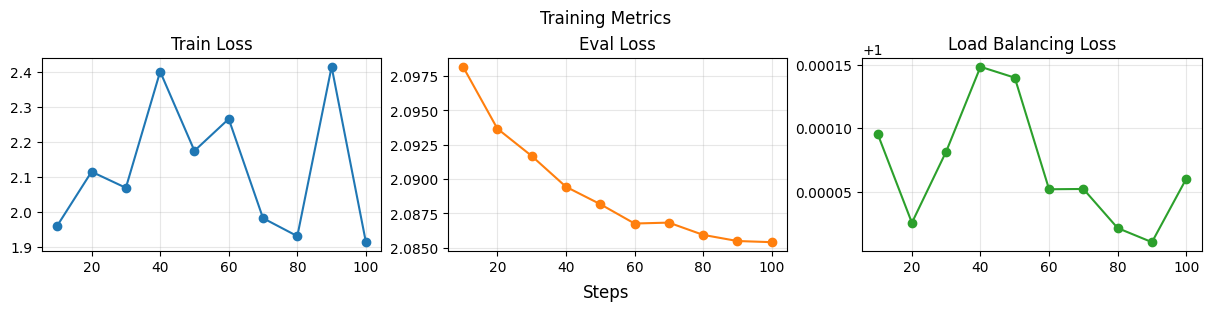

In [ ]:
######################################################################################################################
############################################## DO NOT CHANGE[START] ##################################################
######################################################################################################################

# Verify plots
x_vals = [REPORT_AFTER_N_STEPS * i for i in range(1, len(training_metrics['Train Loss'])+1)]
plot_metrics(training_metrics, x_vals=x_vals, suptitle="Training Metrics")

######################################################################################################################
############################################## DO NOT CHANGE[END] ####################################################
######################################################################################################################

#### Plot MoE Metric with Explanation(🚨 1 points)

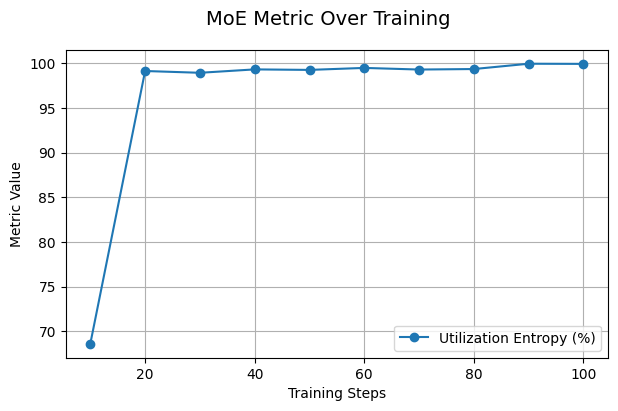

In [ ]:
######################################################################################################################
############################################## PLOT YOUR CUSTOM MOE METRICS ##################################################
######################################################################################################################

def plot_custom_metric(metrics: dict, suptitle=None, x_vals=None):
    fig, ax = plt.subplots(figsize=(7,4))
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)

    for name, vals in metrics.items():
        if x_vals is None:
            ax.plot(range(1, len(vals)+1), vals, marker="o", label=name)
        else:
            ax.plot(x_vals, vals, marker="o", label=name)

    ax.set_xlabel("Training Steps")
    ax.set_ylabel("Metric Value")
    ax.legend()
    ax.grid(True)
    plt.show()

x_vals = [REPORT_AFTER_N_STEPS * i for i in range(1, len(moe_metrics[custom_moe_metric.label])+1)]
plot_custom_metric(moe_metrics, suptitle="MoE Metric Over Training", x_vals=x_vals)

### Why I chose `Expert/Utilization Entropy`
I chose utilization entropy because it provides a simple, interpretable percentage that directly reflects whether the router is collapsing to one expert or using all experts. It complements the load-balancing loss and is lightweight enough to compute during training.

In [ ]:
#💡 Verify that the model didn't collapse and can still generate coherent text.
#   You dont expect this to be the same as the dense model, but should still be coherent
__test_model.to('cpu')
__test_model.eval()

generation_compare(
    prompt=TEST_PROMPT,
    tokenizer=tokenizer,
    num_tokens=50,
    model_A= dense_model,
    model_B=__test_model
)

######################################################################################################################
############################################### DO NOT CHANGE[END] ###################################################
######################################################################################################################


>>>>>>>>>>>>>>>>>>>>
	Prompt
<<<<<<<<<<<<<<<<<<<<
Where is the Great Wall?


time=2.150s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_A Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

The Great Wall of China is the longest wall in the world. It stretches over 13,000 miles and is 13,000 feet high. It is located in the northern part of China, in the country



time=3.909s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_B Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

The Great Wall of China is a massive wall of stone and brick that stretches over 13,000 miles from the city of Beijing in China to the city of Shanxi in Shaanxi province. It is the longest wall in


# **Coding Challenge Part 4:  Exploring The Unknown 🧙 ✨ [🚨 5 points]**

In this part, you can choose any one of the provided questions below.

Both questions are open-ended, and there is no one single solution -- you can follow any paper you find related to the question you picked and also you can be fully creative.

We want to see how you will approach the problem and how you will show that your approach is working.    

1. **Make training more efficient with dataset intervention:** Now you can process the whole dataset ([cosmopedia-100k](https://huggingface.co/datasets/HuggingFaceTB/cosmopedia-100k), but you can only sample the same number of examples (1000). How would you modify/filter the original dataset for making the training more efficient?

2. **Explore methods to increase expert specilization for given datasets:** You are given these 3 datasets inside [Nemotron-Post-Training-Dataset (SFT partition)](https://huggingface.co/datasets/nvidia/Llama-Nemotron-Post-Training-Dataset): [chat, math and code subsets](https://huggingface.co/datasets/nvidia/Llama-Nemotron-Post-Training-Dataset#filtering-the-data); develop training methods/pipelines that increase expert specialization for each data. (Each expert will focus on one of these datasets rathen than distributing uniformly.)

**NOTE:** If your MoE implementation does not work, you can pick the 1 question and show the effectiness of your method on dense model training.


## Expert Specialization for given datasets 🏋

### 1. Setup

In [ ]:
import re
from typing import List, Tuple, Union, Optional, Dict
from datasets import interleave_datasets, Dataset, DatasetDict


def strip_think(text: str) -> str:
    """
    Remove <think>...</think> annotations (used for reasoning traces)
    from model outputs.

    Args:
        text (str): Input text string (may include <think> tags).

    Returns:
        str: Cleaned string with <think> sections removed.
    """
    if not isinstance(text, str):
        return str(text)
    # Remove <think>...</think> blocks (greedy match across multiple lines)
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    # Remove any remaining <think>... at the end of the string
    text = re.sub(r"<think>.*$", "", text, flags=re.DOTALL)
    return text.strip()


def find_subseq(seq: List[int], pat: List[int]) -> int:
    """
    Find the first occurrence of a subsequence inside a sequence.

    Args:
        seq (List[int]): Sequence of tokens.
        pat (List[int]): Subsequence to search for.

    Returns:
        int: Starting index of the subsequence if found, else -1.
    """
    L, M = len(seq), len(pat)
    for i in range(L - M + 1):
        if seq[i:i+M] == pat:
            return i
    return -1


# Mapping from domain names to IDs (used as supervision signal for routing in MoE)
DOMAIN_TO_ID: Dict[str, int] = {"chat": 0, "code": 1, "math": 2}


def build_dataset(
    dataset_id: str,
    subset: Optional[str],
    splits: List[str],
    tokenizer,
    block_size: int,
    max_samples: Optional[int] = None,
    val_fraction: float = 0.1,
    seed: int = 42,
) -> Union[Dataset, Tuple[Dataset, Dataset]]:
    """
    Build a tokenized dataset for multi-domain training with domain supervision.

    Each sample is formatted as:
        ### Input:
        {input text}

        ### Output:
        {output text}

    The labels are masked so that:
      - Padding tokens are ignored (-100).
      - Input text and the "### Output:" marker are masked (-100),
        so loss is only computed on the actual output text.

    Args:
        dataset_id (str): Hugging Face dataset ID.
        subset (str, optional): Dataset subset name.
        splits (List[str]): Splits to load (e.g., ["chat", "code", "math"]).
        tokenizer (PreTrainedTokenizerBase): Hugging Face tokenizer instance.
        block_size (int): Max token sequence length (for truncation/padding).
        max_samples (int, optional): Limit number of samples per split (debugging).
        val_fraction (float, optional): Fraction of data for validation split.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        Union[Dataset, Tuple[Dataset, Dataset]]:
            - If val_fraction is set: (train_ds, val_ds)
            - Else: A single balanced dataset.
    """
    domain_datasets: List[Dataset] = []

    # Ensure pad token exists (important for LLaMA-style models)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    for split in splits:
        # Load dataset for a given split
        ds: Dataset = load_dataset(dataset_id, subset, split=split)
        if max_samples is not None:
            ds = ds.select(range(max_samples))

        # Assign domain ID (e.g., "chat" -> 0, "code" -> 1)
        dom_id = DOMAIN_TO_ID[split]

        MARKER = "### Output:\n"

        def format_sample(example: Dict) -> Dict[str, Union[str, int]]:
            """
            Convert a raw dataset sample into formatted text with Input/Output sections.

            Args:
                example (Dict): A raw dataset entry with keys "input" and "output".

            Returns:
                Dict[str, Union[str, int]]: Dict with {"text": str, "domain_id": int}.
            """
            inp = example["input"]
            if isinstance(inp, list):
                # Convert structured conversation history into text
                inp = "\n".join(
                    f"{m.get('role','user').capitalize()}: {m.get('content','')}"
                    for m in inp
                )
            out_clean = strip_think(example["output"])  # remove reasoning traces
            text = (
                f"### Input:\n{inp}\n\n"
                f"{MARKER}{out_clean}"
            )
            return {"text": text, "domain_id": dom_id}

        # Map raw dataset into formatted text
        ds = ds.map(format_sample)

        def tok(batch: Dict) -> Dict:
            """
            Tokenize a batch of formatted samples and create labels:
              - Pads -> -100
              - Input section (including marker) -> -100
              - Output tokens -> normal labels

            Args:
                batch (Dict): A batch with keys "text" and "domain_id".

            Returns:
                Dict: Encoded features including input_ids, attention_mask,
                      labels, and domain_id.
            """
            enc = tokenizer(
                batch["text"],
                truncation=True,
                max_length=block_size,
                padding="max_length",
                return_attention_mask=True,
            )

            # Start with labels = input_ids
            labels = [row[:] for row in enc["input_ids"]]
            pad_id = tokenizer.pad_token_id
            marker_ids = tokenizer(MARKER, add_special_tokens=False)["input_ids"]

            for i, row in enumerate(labels):
                # Mask padding tokens
                labels[i] = [t if t != pad_id else -100 for t in row]

                # Find position of "### Output:\n" and mask everything before it
                j = find_subseq(row, marker_ids)
                if j != -1:
                    cutoff = j + len(marker_ids)
                    labels[i][:cutoff] = [-100] * cutoff

            # Attach labels and domain_id to batch
            enc["labels"] = labels
            enc["domain_id"] = batch["domain_id"]
            return enc

        # Tokenize dataset and keep only model inputs
        ds = ds.map(tok, batched=True, remove_columns=ds.column_names)
        domain_datasets.append(ds)

    # Interleave datasets to balance domains
    balanced: Dataset = interleave_datasets(
        domain_datasets,
        probabilities=[1/len(splits)]*len(splits),
        seed=seed
    )

    # Train/Validation split
    if val_fraction and 0.0 < val_fraction < 1.0:
        balanced: DatasetDict = balanced.train_test_split(
            test_size=val_fraction, seed=seed, shuffle=True
        )
        train_ds, val_ds = balanced["train"], balanced["test"]

        # Convert to PyTorch tensors
        train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels", "domain_id"])
        val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels", "domain_id"])
        return train_ds, val_ds

    # Only training set
    balanced.set_format(type="torch", columns=["input_ids", "attention_mask", "labels", "domain_id"])
    return balanced

In [ ]:
BATCH_SIZE = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = (device.type == "cuda")

train_ds, val_ds = build_dataset(
    dataset_id="nvidia/Llama-Nemotron-Post-Training-Dataset",
    subset="SFT",
    splits=["chat","code","math"],
    tokenizer=tokenizer,
    block_size=256,
    val_fraction=0.1,
    max_samples=1000
)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=pin
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=pin
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Train dataset size: {len(train_ds)} | Val dataset size: {len(val_ds)}")

Loading dataset shards:   0%|          | 0/91 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/141 [00:00<?, ?it/s]

Train batches: 668 | Val batches: 75
Train dataset size: 2675 | Val dataset size: 298


In [ ]:
def get_domain_probs(step: int, total_steps: int, focus: int | None = None) -> list[float]:
    """
    Compute sampling probabilities for domains [chat, code, math]
    during curriculum training.

    - At the beginning, sampling is biased (by default towards chat).
    - If `focus` is provided (0=chat, 1=code, 2=math),
      that domain is given higher initial probability.
    - Probabilities anneal linearly over time toward uniform [1/3, 1/3, 1/3].

    Args:
        step (int): Current training step.
        total_steps (int): Total number of training steps.
        focus (int | None): Optional domain to emphasize early on.

    Returns:
        list[float]: Probability distribution [p_chat, p_code, p_math].
    """
    progress = step / max(1, total_steps)   # fraction of training completed
    end = [1/3, 1/3, 1/3]                   # final uniform distribution

    if focus is None:
        # Default bias: start mostly in "chat" domain
        start = [0.8, 0.1, 0.1]
    else:
        # Bias toward a specific domain (focus index gets higher prob)
        start = [0.1, 0.1, 0.1]
        start[focus] = 0.8

    # Linear interpolation between start and end distributions
    return [(1 - progress) * s + progress * e for s, e in zip(start, end)]

In [ ]:
import random

# Split training dataset by domain ID (0=chat, 1=code, 2=math)
domain_subsets = {
    d: train_ds.filter(lambda ex: ex["domain_id"] == d)
    for d in DOMAIN_TO_ID.values()
}

# Create a separate DataLoader for each domain
# - shuffle=True ensures domain data is randomized each epoch
# - drop_last=True ensures consistent batch size
domain_loaders = {
    d: iter(torch.utils.data.DataLoader(
        subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    ))
    for d, subset in domain_subsets.items()
}


class CurriculumBatcher:
    """
    A custom batcher that samples batches from different domain-specific DataLoaders
    according to a curriculum schedule.

    - Early in training: biased toward one domain (e.g., chat).
    - Later in training: gradually anneals to uniform domain sampling.
    """

    def __init__(self, domain_loaders: dict[int, iter], total_steps: int) -> None:
        """
        Args:
            domain_loaders (dict[int, Iterator]): Mapping from domain_id -> DataLoader iterator.
            total_steps (int): Total number of training steps.
        """
        self.domain_loaders = domain_loaders
        self.total_steps = total_steps
        self.step = 0

    def next_batch(self, target_domain: int | None = None) -> dict:
        """
        Retrieve the next batch according to the curriculum probabilities.

        Args:
            target_domain (int | None): If specified, bias sampling toward this domain.

        Returns:
            dict: A batch of tokenized samples (torch tensors).
        """
        # Compute domain sampling probabilities for this step
        probs = get_domain_probs(self.step, self.total_steps, focus=target_domain)
        keys = list(self.domain_loaders.keys())

        # Randomly choose a domain according to probs
        domain = random.choices(keys, weights=probs)[0]

        try:
            # Try to fetch next batch from chosen domain loader
            batch = next(self.domain_loaders[domain])
        except StopIteration:
            # If exhausted, reinitialize DataLoader for that domain
            # (shuffle=True ensures data reshuffling once per new epoch)
            self.domain_loaders[domain] = iter(torch.utils.data.DataLoader(
                domain_subsets[domain],
                batch_size=BATCH_SIZE,
                shuffle=True,
                drop_last=True
            ))
            batch = next(self.domain_loaders[domain])

        # Advance curriculum step counter
        self.step += 1
        return batch

### 2. Training

In [ ]:
############################################
############# Training Settings ############
############################################

STEPS = 100
REPORT_AFTER_N_STEPS = 10

LEARNING_RATE = 5e-5
WEIGHT_DECAY  = 0.1
WARMUP_STEPS  = max(5, REPORT_AFTER_N_STEPS)

# Domain-Supervised Routing (DSR)
LAMBDA_ROUTE = 0.5               # weight for cross-entropy loss aligning domain_id -> expert

# Gating temperature schedule
# Controls softmax sharpness when assigning tokens to experts
GATE_TAU_START     = 1.0         # high -> softer distribution (more exploration)
GATE_TAU_END       = 0.3         # low -> sharper distribution (commitment)
GATE_TAU_WARM_FRAC = 0.20        # fraction of total STEPS used for annealing

def get_gate_tau(step: int) -> float:
    """
    Anneal gate temperature τ linearly from START -> END
    over the warmup fraction of training steps.

    Args:
        step (int): Current training step.

    Returns:
        float: Gate temperature τ.
    """
    warm_steps = max(1, int(GATE_TAU_WARM_FRAC * STEPS))
    if step <= warm_steps:
        t = step / warm_steps
        return (1 - t) * GATE_TAU_START + t * GATE_TAU_END
    return GATE_TAU_END

# Expert dropout
P_EXPERT_DROPOUT = 0.2           # probability of masking router decision -> forces domain-based routing

# Knowledge distillation (KD)
KD_TEMP = 2.0                    # softmax temperature for teacher/student KL divergence
LAMBDA_KD = 0.2                  # weight of KD loss relative to LM loss

# Router noise injection (noisy top-1 routing)
ROUTER_NOISE_START = 0.5         # initial Gaussian noise std
ROUTER_NOISE_END   = 0.0         # no noise at the end
ROUTER_NOISE_WARM_FRAC = 0.3     # anneal noise down over 30% of training

# Domain prefix embeddings
PREFIX_LEN = 1                   # number of prefix tokens per domain
PREFIX_DIM = config.hidden_size  # embedding dimension = model hidden size
NUM_DOMAINS = len(DOMAIN_TO_ID)  # e.g. chat, code, math

# Learnable prefix embeddings (prepended to input sequence, conditioned on domain)
domain_prefix_emb = nn.Embedding(NUM_DOMAINS, PREFIX_LEN * PREFIX_DIM).to(device)

############################################
############## OPTIMIZER ###################
############################################

# Separate parameters for router vs. other weights
router_params, other_params = [], []
for name, p in __test_model.named_parameters():
    if not p.requires_grad:
        continue
    if name.endswith(".moe.gate.weight"):
        router_params.append(p)     # router gate parameters (use higher LR)
    else:
        other_params.append(p)      # everything else

# AdamW optimizer with parameter groups
opt = torch.optim.AdamW(
    [
        {"params": other_params,  "lr": LEARNING_RATE},
        {"params": router_params, "lr": LEARNING_RATE * 2.0},  # faster learning for router
        {"params": domain_prefix_emb.parameters(), "lr": LEARNING_RATE},  # prefixes
    ],
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),  # AdamW betas (slightly higher β2 than default)
    eps=1e-8,           # small epsilon for numerical stability
)

############################################
############ Learning Rate Scheduler #######
############################################
from torch.optim.lr_scheduler import LambdaLR

def _lr_lambda(step: int) -> float:
    """
    Piecewise learning rate schedule:
      - Linear warmup for WARMUP_STEPS.
      - Cosine decay from warmup to STEPS.

    Args:
        step (int): Current training step.

    Returns:
        float: Scaling factor applied to base LR.
    """
    if step < WARMUP_STEPS:
        # Linear warmup from 0 -> 1
        return float(step + 1) / float(max(1, WARMUP_STEPS))
    # Cosine decay after warmup
    progress = (step - WARMUP_STEPS) / float(max(1, STEPS - WARMUP_STEPS))
    return 0.5 * (1.0 + math.cos(math.pi * min(1.0, max(0.0, progress))))

# LR scheduler (LambdaLR applies _lr_lambda scaling)
scheduler = LambdaLR(opt, lr_lambda=_lr_lambda)

#### Helper functions

In [ ]:
############################################
############## HELPER FNS ##################
############################################

def causal_lm_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    attention_mask: torch.Tensor
) -> torch.Tensor:
    """
    Compute masked causal language modeling (next-token prediction) loss.

    Args:
        logits (torch.Tensor): Model output logits, shape [B, T, V].
        labels (torch.Tensor): Ground-truth token IDs, shape [B, T], may contain -100 for masked positions.
        attention_mask (torch.Tensor): Attention mask, shape [B, T], 1=valid token, 0=padding.

    Returns:
        torch.Tensor: Scalar tensor containing the normalized loss.
    """
    # Shift logits/labels so that token t is predicted from inputs up to t-1
    shift_logits = logits[:, :-1, :].contiguous()   # [B, T-1, V]
    shift_labels = labels[:, 1:].contiguous()       # [B, T-1]
    shift_mask   = attention_mask[:, 1:].contiguous().float()  # [B, T-1]

    # Flatten for efficient loss computation
    B, Tm1, V = shift_logits.shape
    shift_logits = shift_logits.view(B * Tm1, V)
    shift_labels = shift_labels.view(B * Tm1)
    shift_mask   = shift_mask.view(B * Tm1)

    # Compute cross-entropy loss, ignoring -100, then mask pads
    ce = F.cross_entropy(shift_logits, shift_labels, reduction="none", ignore_index=-100)
    ce = ce * shift_mask

    # Normalize loss by number of valid tokens
    denom = torch.clamp(shift_mask.sum(), min=1.0)
    return ce.sum() / denom


@torch.no_grad()
def evaluate_loss(model: nn.Module, dataloader: torch.utils.data.DataLoader, max_batches: int = 20) -> float:
    """
    Evaluate the average causal LM loss over a subset of validation batches.

    Args:
        model (nn.Module): MoE model to evaluate.
        dataloader (DataLoader): Validation data loader.
        max_batches (int, optional): Maximum number of batches to evaluate. Defaults to 20.

    Returns:
        float: Average validation loss.
    """
    was_training = model.training
    model.eval()
    total, count = 0.0, 0
    it = iter(dataloader)

    for _ in range(max_batches):
        try:
            batch = next(it)
        except StopIteration:
            break

        # Move inputs to device
        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels         = batch["labels"].to(device, non_blocking=True)
        domain_ids     = batch["domain_id"].to(device, non_blocking=True)

        # Add domain-specific prefix embeddings
        inputs_embeds, new_attention_mask = add_domain_prefix(
            input_ids, attention_mask, domain_ids, model, domain_prefix_emb
        )

        # Adjust labels: prefix tokens are never predicted
        prefix_pad = torch.full((labels.size(0), PREFIX_LEN), -100, dtype=labels.dtype, device=labels.device)
        new_labels = torch.cat([prefix_pad, labels], dim=1)

        # Forward pass (with mixed precision if enabled)
        if scaler_enabled:
            with torch.autocast(device_type="cuda", dtype=autocast_dtype):
                out = forward_with_prefix(model, new_attention_mask, inputs_embeds)
                logits = out["logits"]
                loss = causal_lm_loss(logits, new_labels, new_attention_mask)
        else:
            out = forward_with_prefix(model, new_attention_mask, inputs_embeds)
            logits = out["logits"]
            loss = causal_lm_loss(logits, new_labels, new_attention_mask)

        total += float(loss.item())
        count += 1

    if was_training:
        model.train()
    return total / max(1, count)


# Domain-Supervised Routing (DSR) Loss

DOMAIN_TO_EXPERT: dict[int, int] = {0: 0, 1: 1, 2: 2}  # chat→0, code→1, math→2

def router_supervision_loss(model: nn.Module, domain_ids: torch.Tensor, tau: float) -> torch.Tensor:
    """
    Cross-entropy loss on router logits using domain_id -> expert mapping.
    Uses only the first token (domain prefix) from each sequence.

    Args:
        model (nn.Module): MoE model.
        domain_ids (torch.Tensor): Domain IDs for each sequence [B].
        tau (float): Softmax temperature.

    Returns:
        torch.Tensor: Router supervision loss (scalar).
    """
    router_logits = []
    for layer in model.model.layers:
        if hasattr(layer, "moe") and hasattr(layer.moe, "_last_router_logits"):
            router_logits.append(layer.moe._last_router_logits)  # [B, T, E]

    if not router_logits:
        return torch.tensor(0.0, device=domain_ids.device)

    # Average router logits across layers
    avg_logits = torch.stack(router_logits, dim=0).mean(dim=0)  # [B, T, E]
    first_logits = avg_logits[:, 0, :]                          # [B, E]

    # Map domain IDs to target experts
    targets = torch.tensor(
        [DOMAIN_TO_EXPERT[int(d)] for d in domain_ids.tolist()],
        device=first_logits.device, dtype=torch.long
    )

    # Compute CE loss
    log_probs = F.log_softmax(first_logits / tau, dim=-1)
    return F.nll_loss(log_probs, targets)


# Expert Dropout (Routing Masking)

def apply_expert_dropout(model: nn.Module, domain_ids: torch.Tensor, step: int, p_drop: float = P_EXPERT_DROPOUT) -> None:
    """
    With probability p_drop, mask router logits so that tokens from a domain
    can only route to their assigned expert. This nudges experts to specialize.

    Args:
        model (nn.Module): MoE model.
        domain_ids (torch.Tensor): Domain IDs for each sequence [B].
        step (int): Current training step.
        p_drop (float, optional): Probability of applying dropout. Defaults to P_EXPERT_DROPOUT.
    """
    if torch.rand(1).item() > p_drop:
        return  # no masking this step

    for layer in model.model.layers:
        moe = getattr(layer, "moe", None)
        if moe is None or not hasattr(moe, "_last_router_logits"):
            continue

        logits = moe._last_router_logits  # [B, T, E]
        B, T, E = logits.shape
        mask = torch.full_like(logits, float("-inf"))

        # Allow only the target expert for each domain
        for b in range(B):
            target_e = DOMAIN_TO_EXPERT[int(domain_ids[b].item())]
            mask[b, :, target_e] = 0.0

        moe._last_router_logits = logits + mask


def domain_conditional_kd_loss(
    teacher_model: nn.Module,
    moe_model: nn.Module,
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    domain_ids: torch.Tensor,
    temp: float = KD_TEMP
) -> torch.Tensor:
    """
    Domain-conditional knowledge distillation (KD) loss.

    Computes KL divergence between teacher and MoE student
    distributions, separately per domain, then averages.

    Args:
        teacher_model (nn.Module): Teacher dense model.
        moe_model (nn.Module): Student MoE model.
        input_ids (torch.Tensor): Token IDs [B, T].
        attention_mask (torch.Tensor): Attention mask [B, T].
        domain_ids (torch.Tensor): Domain IDs [B].
        temp (float, optional): Softmax temperature. Defaults to KD_TEMP.

    Returns:
        torch.Tensor: KD loss (scalar).
    """
    with torch.no_grad():
        teacher_logits = teacher_model(
            input_ids=input_ids, attention_mask=attention_mask
        )["logits"]
        teacher_probs = F.softmax(teacher_logits / temp, dim=-1)

    student_logits = moe_model(
        input_ids=input_ids, attention_mask=attention_mask
    )["logits"]
    student_log_probs = F.log_softmax(student_logits / temp, dim=-1)

    # --- Domain-conditional KL ---
    losses = []
    for dom in torch.unique(domain_ids):
        mask = domain_ids == dom
        if mask.any():
            t_probs = teacher_probs[mask]
            s_logp = student_log_probs[mask]
            dom_loss = F.kl_div(s_logp, t_probs, reduction="batchmean")
            losses.append(dom_loss)

    if len(losses) == 0:
        return torch.tensor(0.0, device=input_ids.device)

    kd_loss = torch.stack(losses).mean() * (temp * temp)
    return kd_loss



# Router Noise Injection

def get_router_noise(step: int) -> float:
    """
    Compute annealed standard deviation for Gaussian noise in router logits.

    Args:
        step (int): Current training step.

    Returns:
        float: Noise standard deviation.
    """
    warm_steps = int(STEPS * ROUTER_NOISE_WARM_FRAC)
    if step <= warm_steps:
        t = step / warm_steps
        return (1 - t) * ROUTER_NOISE_START + t * ROUTER_NOISE_END
    return ROUTER_NOISE_END


def apply_router_noise(model: nn.Module, step: int) -> None:
    """
    Add Gaussian noise to stored router logits (in-place).
    Equivalent to Noisy Top-k routing but without modifying MoE.forward().

    Args:
        model (nn.Module): MoE model.
        step (int): Current training step.
    """
    sigma = get_router_noise(step)
    if sigma <= 0:
        return

    for layer in model.model.layers:
        moe = getattr(layer, "moe", None)
        if moe is not None and hasattr(moe, "_last_router_logits"):
            logits = moe._last_router_logits
            moe._last_router_logits = logits + torch.randn_like(logits) * sigma


# Add Learnable Domain Prefix Embeddings

def add_domain_prefix(
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    domain_ids: torch.Tensor,
    model: nn.Module,
    prefix_emb_module: nn.Embedding
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Prepend learned domain prefix embeddings to the input sequence.

    Args:
        input_ids (torch.Tensor): Token IDs [B, T].
        attention_mask (torch.Tensor): Attention mask [B, T].
        domain_ids (torch.Tensor): Domain IDs [B].
        model (nn.Module): MoE model (provides token embeddings).
        prefix_emb_module (nn.Embedding): Embedding for domain prefixes.

    Returns:
        tuple[torch.Tensor, torch.Tensor]:
            - new_inputs_embeds: [B, T+PREFIX_LEN, H]
            - new_attention_mask: [B, T+PREFIX_LEN]
    """
    B, T = input_ids.shape
    H = model.model.embed_tokens.embedding_dim

    # 1. Embed tokens as usual
    token_embeds = model.model.embed_tokens(input_ids)   # [B, T, H]

    # 2. Embed domain-specific prefixes
    prefix_raw = prefix_emb_module(domain_ids)           # [B, PREFIX_LEN*H]
    prefix = prefix_raw.view(B, PREFIX_LEN, H)           # [B, PREFIX_LEN, H]

    # 3. Concatenate prefix + tokens
    new_inputs_embeds = torch.cat([prefix, token_embeds], dim=1)

    # 4. Extend attention mask (prefix tokens are always active)
    prefix_mask = torch.ones((B, PREFIX_LEN), dtype=attention_mask.dtype, device=attention_mask.device)
    new_attention_mask = torch.cat([prefix_mask, attention_mask], dim=1)

    return new_inputs_embeds, new_attention_mask


def forward_with_prefix(model: nn.Module, attention_mask: torch.Tensor, inputs_embeds: torch.Tensor) -> dict[str, torch.Tensor]:
    """
    Custom forward pass that uses precomputed embeddings (prefix + tokens).
    Mirrors smolMoELM.forward but skips token embedding lookup.

    Args:
        model (nn.Module): MoE model.
        attention_mask (torch.Tensor): Attention mask [B, T+PREFIX_LEN].
        inputs_embeds (torch.Tensor): Input embeddings [B, T+PREFIX_LEN, H].

    Returns:
        dict[str, torch.Tensor]: Dict with {"logits": logits}.
    """
    hidden_states = inputs_embeds

    # Forward through decoder layers
    for decoder_layer in model.model.layers:
        layer_outputs = decoder_layer(hidden_states, attention_mask=attention_mask)
        hidden_states = layer_outputs[0]

    # Final normalization + LM head
    hidden_states = model.model.norm(hidden_states)
    logits = model.lm_head(hidden_states)
    return {"logits": logits.float()}


# Expert-Domain Alignment Metric

@labelthis("Expert-Domain Alignment (%)")
@torch.no_grad()
def expert_domain_alignment(model: nn.Module, dataloader: torch.utils.data.DataLoader, sample_batches: int = 5) -> float:
    """
    Measure how often tokens are routed to the expected expert (domain->expert mapping).

    Args:
        model (nn.Module): MoE model.
        dataloader (DataLoader): Validation dataloader.
        sample_batches (int, optional): Number of batches to sample. Defaults to 5.

    Returns:
        float: Percentage of tokens routed correctly.
    """
    was_training = model.training
    model.eval()

    correct, total = 0, 0
    it = iter(dataloader)

    for _ in range(sample_batches):
        try:
            batch = next(it)
        except StopIteration:
            break

        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        domain_ids     = batch["domain_id"].to(device, non_blocking=True)

        # Forward pass to populate router logits
        with torch.autocast(device_type="cuda", dtype=autocast_dtype) if scaler_enabled else torch.no_grad():
            _ = model(input_ids=input_ids, attention_mask=attention_mask)

        # Collect router assignments from each MoE layer
        for layer in model.model.layers:
            moe = getattr(layer, "moe", None)
            if moe is None or not hasattr(moe, "_last_router_logits"):
                continue
            assignments = torch.argmax(moe._last_router_logits, dim=-1)  # [B, T]

            # Expected expert for each domain
            targets = torch.tensor(
                [DOMAIN_TO_EXPERT[int(d.item())] for d in domain_ids],
                device=assignments.device
            ).unsqueeze(1).expand_as(assignments)  # [B, T]

            # Count matches
            correct += (assignments == targets).sum().item()
            total   += assignments.numel()

    if was_training:
        model.train()

    return 100.0 * correct / max(1, total)

#### Training loop

In [ ]:
edas_metric = expert_domain_alignment(__test_model, val_loader)
print(f"[Before Training : Sanity Check] EDAS: {edas_metric:.1f}%\n")

t0 = time.time()

training_metrics = {
    'Train Loss': [],
    'Eval Loss': [],
    'Router Supervision Loss': [],
    'KD Loss': []
}
moe_metrics = {
    expert_domain_alignment.label: []
}

__test_model.train()
curriculum_batcher = CurriculumBatcher(domain_loaders, STEPS)


for step in range(1, STEPS + 1):

    ###################################################
    ############## Training Section ###################
    ###################################################
    batch = curriculum_batcher.next_batch()

    input_ids      = batch["input_ids"].to(device, non_blocking=True)
    attention_mask = batch["attention_mask"].to(device, non_blocking=True)
    labels         = batch["labels"].to(device, non_blocking=True)
    domain_ids     = batch["domain_id"].to(device, non_blocking=True)

    inputs_embeds, new_attention_mask = add_domain_prefix(
        input_ids, attention_mask, domain_ids, __test_model, domain_prefix_emb
    )

    prefix_pad = torch.full((labels.size(0), PREFIX_LEN), -100, dtype=labels.dtype, device=labels.device)
    new_labels = torch.cat([prefix_pad, labels], dim=1)

    opt.zero_grad(set_to_none=True)

    if scaler_enabled:
        with torch.autocast(device_type="cuda", dtype=autocast_dtype):
            out = forward_with_prefix(__test_model, new_attention_mask, inputs_embeds)
            logits = out["logits"]

            lm_loss = causal_lm_loss(logits, new_labels, new_attention_mask)
            tau = get_gate_tau(step)
            route_loss = router_supervision_loss(__test_model, domain_ids, tau)
            kd_loss = domain_conditional_kd_loss(dense_model, __test_model, input_ids, attention_mask, domain_ids, KD_TEMP)

            apply_router_noise(__test_model, step)
            apply_expert_dropout(__test_model, domain_ids, step)

            total_loss = (
                lm_loss
                + LAMBDA_ROUTE * route_loss
                + LAMBDA_KD * kd_loss
            )
        total_loss.backward()
    else:
        out = forward_with_prefix(__test_model, new_attention_mask, inputs_embeds)
        logits = out["logits"]

        lm_loss = causal_lm_loss(logits, new_labels, new_attention_mask)
        tau = get_gate_tau(step)
        route_loss = router_supervision_loss(__test_model, domain_ids, tau)
        kd_loss = domain_conditional_kd_loss(dense_model, __test_model, input_ids, attention_mask, domain_ids, KD_TEMP)

        apply_router_noise(__test_model, step)
        apply_expert_dropout(__test_model, domain_ids, step)

        total_loss = (
            lm_loss
            + LAMBDA_ROUTE * route_loss
            + LAMBDA_KD * kd_loss
        )
        total_loss.backward()

    params_to_clip = [p for g in opt.param_groups for p in g['params']]
    torch.nn.utils.clip_grad_norm_(params_to_clip, max_norm=1.0)
    opt.step()
    scheduler.step()

    #########################################################
    ############## Eval/Reporting Section ###################
    #########################################################
    if step % REPORT_AFTER_N_STEPS == 0:
        val_loss = evaluate_loss(__test_model, val_loader, max_batches=20)

        training_metrics['Train Loss'].append(float(total_loss.detach().cpu().item()))
        training_metrics['Eval Loss'].append(float(val_loss))
        training_metrics['Router Supervision Loss'].append(float(route_loss.detach().cpu().item()))
        training_metrics['KD Loss'].append(float(kd_loss.detach().cpu().item()))


        edas_metric = expert_domain_alignment(__test_model, val_loader, sample_batches=5)
        moe_metrics[expert_domain_alignment.label].append(edas_metric)

        time_taken = (time.time() - t0)
        print(
            f"Step {step}/{STEPS} | "
            f"Train Loss: {total_loss.item():.3f} | "
            f"Eval Loss: {val_loss:.3f} | "
            f"Route Loss: {route_loss.item():.3f} | "
            f"KD Loss: {kd_loss.item():.3f} | "
            f"{expert_domain_alignment.label}: {edas_metric:.1f}% | "
            f"Time Taken: {pretty_dt(time_taken)}"
        )
        print("***"*60)
        t0 = time.time()

[Before Training : Sanity Check] EDAS: 25.7%

Step 10/100 | Train Loss: 2.907 | Eval Loss: 1.433 | Route Loss: 1.083 | KD Loss: 3.704 | Expert-Domain Alignment (%): 28.7% | Time Taken: 1m 5s
************************************************************************************************************************************************************************************
Step 20/100 | Train Loss: 8.925 | Eval Loss: 1.433 | Route Loss: 1.129 | KD Loss: 38.058 | Expert-Domain Alignment (%): 29.8% | Time Taken: 1m 0s
************************************************************************************************************************************************************************************
Step 30/100 | Train Loss: 3.543 | Eval Loss: 1.426 | Route Loss: 0.948 | KD Loss: 1.781 | Expert-Domain Alignment (%): 31.7% | Time Taken: 1m 2s
************************************************************************************************************************************************************

### 3. Test & Visualization

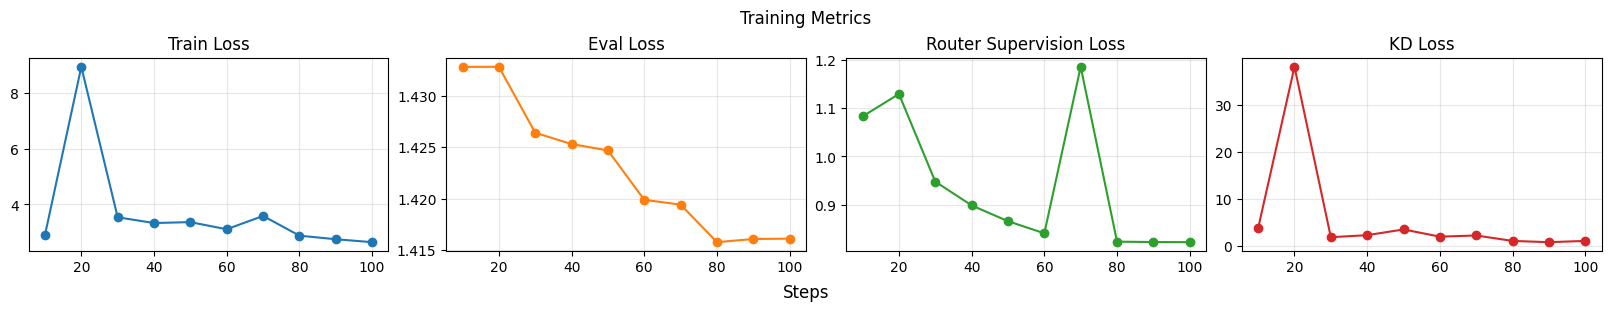

In [ ]:
x_vals = [REPORT_AFTER_N_STEPS * i for i in range(1, len(training_metrics['Train Loss'])+1)]
plot_metrics(training_metrics, x_vals=x_vals, suptitle="Training Metrics")

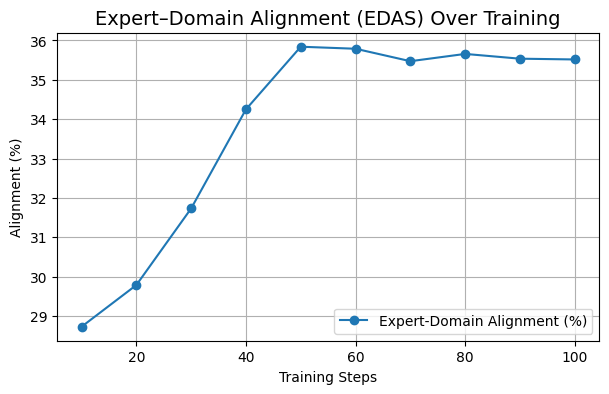

In [ ]:
# Extract EDAS curve
x_vals = [REPORT_AFTER_N_STEPS * i for i in range(1, len(moe_metrics[expert_domain_alignment.label])+1)]
edas_vals = moe_metrics[expert_domain_alignment.label]

# Plot EDAS
plt.figure(figsize=(7,4))
plt.plot(x_vals, edas_vals, marker="o", label=expert_domain_alignment.label, color="tab:blue")
plt.title("Expert–Domain Alignment (EDAS) Over Training", fontsize=14)
plt.xlabel("Training Steps")
plt.ylabel("Alignment (%)")
plt.grid(True)
plt.legend()
plt.show()

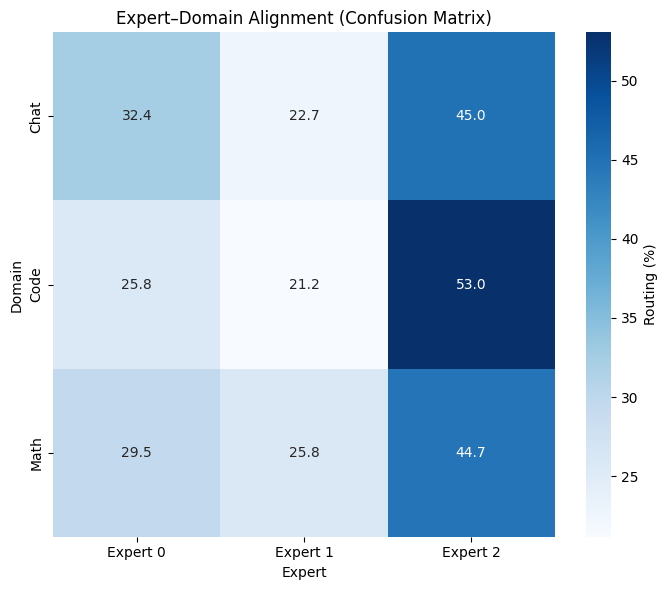

In [ ]:
import seaborn as sns

@torch.no_grad()
def plot_edas_confusion_matrix(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    sample_batches: int = 10
) -> np.ndarray:
    """
    Build and plot a confusion matrix of Expert-Domain Alignment (EDA).

    - Rows represent true domains.
    - Columns represent predicted experts.
    - Each cell is the % of tokens from a domain routed to a given expert.

    Args:
        model (nn.Module): MoE model to evaluate.
        dataloader (DataLoader): Validation dataloader.
        sample_batches (int, optional): Number of batches to process. Defaults to 10.

    Returns:
        np.ndarray: Confusion matrix of shape [num_domains, num_experts] with row-normalized percentages.
    """
    num_experts = config.num_experts
    num_domains = len(DOMAIN_TO_ID)

    # Initialize raw confusion matrix (counts)
    cm = torch.zeros(num_domains, num_experts, device=device)

    it = iter(dataloader)
    for _ in range(sample_batches):
        try:
            batch = next(it)
        except StopIteration:
            break

        # Move batch to device
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        domain_ids     = batch["domain_id"].to(device)

        # Forward pass to populate router logits
        _ = model(input_ids=input_ids, attention_mask=attention_mask)

        # Collect routing decisions from each MoE layer
        for layer in model.model.layers:
            moe = getattr(layer, "moe", None)
            if moe is None or not hasattr(moe, "_last_router_logits"):
                continue

            # Hard assignment: pick expert with max logit
            assignments = torch.argmax(moe._last_router_logits, dim=-1)  # [B, T]

            # Count how many tokens per domain were routed to each expert
            for b, dom in enumerate(domain_ids):
                for exp in range(num_experts):
                    cm[dom, exp] += (assignments[b] == exp).sum()

    # Normalize rows -> convert counts to percentages
    cm = cm.cpu().numpy()
    cm = cm / cm.sum(axis=1, keepdims=True) * 100

    # Plot heatmap
    plt.figure(figsize=(7, 6))
    ax = sns.heatmap(
        cm,
        annot=True,            # show numbers inside cells
        fmt=".1f",             # format with 1 decimal place
        cmap="Blues",          # colormap
        xticklabels=[f"Expert {i}" for i in range(cm.shape[1])],
        yticklabels=[dom.capitalize() for dom in DOMAIN_TO_ID.keys()],
        cbar_kws={'label': 'Routing (%)'}  # colorbar label
    )
    ax.set_title("Expert–Domain Alignment (Confusion Matrix)")
    ax.set_xlabel("Expert")
    ax.set_ylabel("Domain")
    plt.tight_layout()
    plt.show()

    return cm


cm = plot_edas_confusion_matrix(__test_model, val_loader, sample_batches=50)

In [ ]:
# Verify that the model didn't collapse and can still generate coherent text.
__test_model.to('cpu')
__test_model.eval()

generation_compare(
    prompt=TEST_PROMPT,
    tokenizer=tokenizer,
    num_tokens=50,
    model_A= dense_model,
    model_B=__test_model
)


>>>>>>>>>>>>>>>>>>>>
	Prompt
<<<<<<<<<<<<<<<<<<<<
Where is the Great Wall?


time=2.468s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_A Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

The Great Wall of China is the longest wall in the world. It stretches over 13,000 miles and is 13,000 feet high. It is located in the northern part of China, in the country



time=3.950s
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
	Model_B Generation
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

The Great Wall of China is a massive wall of stone and brick that stretches over 13,000 miles from the city of Beijing in China to the city of Shanxi in China. It is the longest wall in the world and
